# From Linear Regression to Deep Learning


**Libraries**: `numpy`, `matplotlib`, `scikit-learn`. Install with `pip install numpy matplotlib scikit-learn` if missing.

---
## Exercise 1: Closed form vs. gradient descent

In Lecture 8 you saw that the least-squares estimates for $\hat y = a + b x$ have a closed form:
$$
b = \frac{\sum (x_i - \bar x)(y_i - \bar y)}{\sum (x_i - \bar x)^2}, \qquad a = \bar y - b \bar x.
$$
In Lecture 9 you saw that deep learning solves the *same kind* of optimization problem using gradient descent. For a simple linear model, the two approaches must agree (up to numerical precision).

**Your task.**
1. Implement the closed-form solution on `(x_train, y_train)` below. Store the estimates as `a_cf`, `b_cf`.
2. Implement vanilla gradient descent on the loss $L(a, b) = \sum_i (y_i - a - b x_i)^2$ with hand-derived gradients. Store the final estimates as `a_gd`, `b_gd`.
3. Plot the training loss vs. iteration. Confirm the final parameters match the closed-form solution.

**Hint.** Standardizing $x$ (zero mean, unit std) before fitting makes gradient descent dramatically easier to tune. The skeleton below does this for you, don't forget to un-standardize the final $(a, b)$.

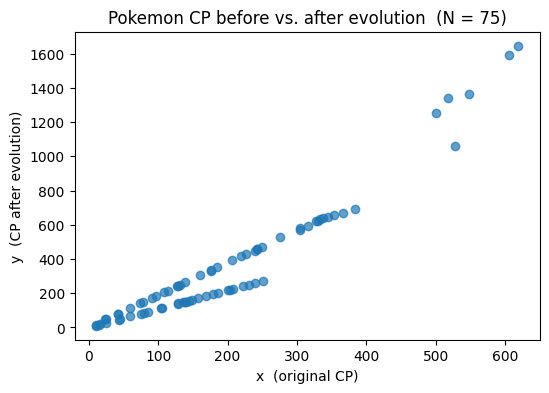

In [2]:
import numpy as np
import matplotlib.pyplot as plt

data = np.genfromtxt('pokemon.csv', delimiter=',', skip_header=1,
                     usecols=(2, 14), invalid_raise=False)
x_train = data[:, 0]          # CP before evolution
y_train = data[:, 1]          # CP after evolution
N = len(x_train)

plt.figure(figsize=(6, 4))
plt.scatter(x_train, y_train, alpha=0.7)
plt.xlabel('x  (original CP)'); plt.ylabel('y  (CP after evolution)')
plt.title(f'Pokemon CP before vs. after evolution  (N = {N})'); plt.show()

In [3]:
# --- Part 1: closed form ---
N = len(x_train)
a_cf = (N * np.sum(x_train * y_train) - np.sum(x_train) * np.sum(y_train)) / \
       (N * np.sum(x_train ** 2) - np.sum(x_train) ** 2)
b_cf = (np.sum(y_train) - a_cf * np.sum(x_train)) / N

print(f'Closed form:      a = {a_cf},  b = {b_cf}')

Closed form:      a = 2.413505081309735,  b = -119.3455085654448


Gradient descent: a = -119.28314637972704,  b = 2.412243940828451


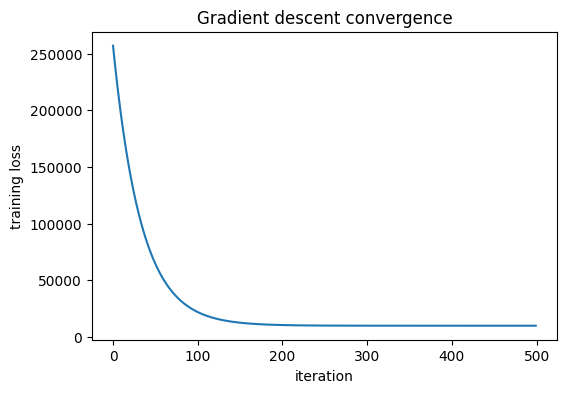

In [6]:
# --- Part 2: gradient descent ---
#
# Loss:          L(a, b) = sum_i (y_i - a - b x_i)^2
# Gradient / a:  dL/da = -2 * sum_i (y_i - a - b x_i)
# Gradient / b:  dL/db = -2 * sum_i x_i * (y_i - a - b x_i)
#
# Tip: standardize x first; it makes the step size robust.

x_mean, x_std = x_train.mean(), x_train.std()
x_tr_z = (x_train - x_mean) / x_std   # standardized x

a, b = 0.0, 0.0        # initial parameters (in standardized space)
lr = 1e-4              # learning rate -- tune this
n_iters = 500
losses = []

for it in range(n_iters):
    y_pred = a + b * x_tr_z
    loss = np.mean((y_train - y_pred) ** 2)
    losses.append(loss)

    grad_a = -2 * np.sum(y_train - y_pred)
    grad_b = -2 * np.sum(x_tr_z * (y_train - y_pred))

    a -= lr * grad_a
    b -= lr * grad_b
    pass

# Convert (a, b) from standardized space back to the original x-scale:
# y = a + b * (x - x_mean) / x_std = (a - b*x_mean/x_std) + (b/x_std) * x
b_gd = b / x_std
a_gd = a - b * x_mean / x_std

print(f'Gradient descent: a = {a_gd},  b = {b_gd}')

plt.figure(figsize=(6, 4))
plt.plot(losses)
plt.xlabel('iteration'); plt.ylabel('training loss')
plt.title('Gradient descent convergence'); plt.show()

- How close are `(a_gd, b_gd)` to `(a_cf, b_cf)`? If they disagree, is the issue the learning rate, the number of iterations, or something else?
- What happens if you bump the learning rate up to `lr = 1.0`? What about `lr = 1e-6`?
- If you skip the standardization of `x`, does the same learning rate still work? Why is standardization so helpful here?

---
## Exercise 2: Watching an MLP learn the two-moons problem

In Exercise 1 we saw that linear regression is really the simplest neural network: one linear output unit, no hidden layer, no activation. For problems where the data is not linearly separable, that isnt enough; no single straight line can split two interleaved crescents.

Here we add **one hidden layer of tanh units** and train the resulting two-layer MLP with plain gradient descent. The network is
$$
\hat y(x) \;=\; \tanh\!\Big(W_2^{\top}\,\tanh(W_1 x + b_1) + b_2\Big), \qquad x \in \mathbb{R}^2,
$$
with $W_1 \in \mathbb{R}^{H \times 2}$ and $W_2 \in \mathbb{R}^{H}$. The geometric picture to keep in mind: each row of $W_1$ defines a line in the input plane, and the corresponding tanh unit produces a soft "half-plane" field -- roughly $+1$ on one side of that line, $-1$ on the other. The output layer takes a weighted vote over these $H$ half-planes, and a final $\tanh$ squashes the vote into a $\pm 1$ prediction.

This exercise is a visualization, not a puzzle. Read the code and run the cells, and analyze

In [ ]:
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=300, noise=0.15, random_state=0)
y_signed = 2 * y - 1            # map labels to +/-1 to match the tanh output range

plt.figure(figsize=(5, 5))
plt.scatter(X[y == 0, 0], X[y == 0, 1], c='#D85A30', s=25,
            edgecolors='white', linewidths=0.4, label='class 0')
plt.scatter(X[y == 1, 0], X[y == 1, 1], c='#534AB7', s=25,
            edgecolors='white', linewidths=0.4, label='class 1')
plt.xlabel('$x_1$'); plt.ylabel('$x_2$')
plt.title('Two moons -- not linearly separable')
plt.legend(); plt.gca().set_aspect('equal')
plt.show()

In [ ]:
# A hand-written two-layer MLP in ~30 lines of numpy.
# Architecture:  2 -> H -> 1 with tanh on both layers.
# Loss:          L = 0.5 * mean((out - y_signed)^2)
# Optimizer:     full-batch gradient descent (no mini-batches, for transparency)
import numpy as np

H = 6
init_rng = np.random.default_rng(seed=1)

W1 = init_rng.normal(0, 1.0,              size=(H, 2))   # one row per hidden neuron
b1 = np.zeros(H)
W2 = init_rng.normal(0, 1.0 / np.sqrt(H), size=H)        # one scalar per hidden neuron
b2 = 0.0

lr = 0.05
n_epochs = 4000
snapshot_epochs = [0, 50, 200, 1000, 2000, n_epochs - 1]

Nsamp = X.shape[0]
losses = []
snapshots = {}

for epoch in range(n_epochs):
    # ---- forward pass ----
    Z1  = X @ W1.T + b1                    # (N, H) hidden pre-activations
    A1  = np.tanh(Z1)                      # (N, H) hidden activations
    z2  = A1 @ W2 + b2                     # (N,)   output pre-activation
    out = np.tanh(z2)                      # (N,)   prediction in [-1, 1]

    # ---- loss ----
    err  = out - y_signed                  # (N,)
    loss = 0.5 * np.mean(err ** 2)
    losses.append(loss)

    # ---- backward pass (chain rule, one line per step) ----
    dz2 = err * (1 - out ** 2) / Nsamp     # (N,)   dL/dz2
    dW2 = A1.T @ dz2                       # (H,)
    db2 = dz2.sum()
    dA1 = np.outer(dz2, W2)                # (N, H)
    dZ1 = dA1 * (1 - A1 ** 2)              # (N, H) tanh' = 1 - tanh^2
    dW1 = dZ1.T @ X                        # (H, 2)
    db1 = dZ1.sum(axis=0)                  # (H,)

    # ---- gradient-descent update ----
    W1 -= lr * dW1;  b1 -= lr * db1
    W2 -= lr * dW2;  b2 -= lr * db2

    if epoch in snapshot_epochs:
        snapshots[epoch] = (W1.copy(), b1.copy(), W2.copy(), b2)

plt.figure(figsize=(6, 3))
plt.plot(losses); plt.xlabel('epoch'); plt.ylabel('training loss (log scale)')
plt.yscale('log'); plt.title('Training loss'); plt.show()

In [ ]:
# Evaluate the network on a dense grid so we can draw its decision surface.
def forward_grid(W1, b1, W2, b2, xx, yy):
    pts = np.stack([xx.ravel(), yy.ravel()], axis=1)
    A1  = np.tanh(pts @ W1.T + b1)
    out = np.tanh(A1 @ W2 + b2)
    return out.reshape(xx.shape)

pad = 0.5
x1g = np.linspace(X[:, 0].min() - pad, X[:, 0].max() + pad, 200)
x2g = np.linspace(X[:, 1].min() - pad, X[:, 1].max() + pad, 200)
xx, yy = np.meshgrid(x1g, x2g)

fig, axes = plt.subplots(1, len(snapshot_epochs), figsize=(16, 3.4))
for ax, ep in zip(axes, snapshot_epochs):
    W1s, b1s, W2s, b2s = snapshots[ep]
    grid = forward_grid(W1s, b1s, W2s, b2s, xx, yy)
    ax.contourf(xx, yy, grid, levels=20, cmap='RdBu', vmin=-1, vmax=1, alpha=0.75)
    ax.contour (xx, yy, grid, levels=[0], colors='k', linewidths=1.2)
    ax.scatter(X[y == 0, 0], X[y == 0, 1], c='#993C1D', s=10,
               edgecolors='white', linewidths=0.4)
    ax.scatter(X[y == 1, 0], X[y == 1, 1], c='#26215C', s=10,
               edgecolors='white', linewidths=0.4)
    ax.set_title(f'epoch {ep}')
    ax.set_xticks([]); ax.set_yticks([]); ax.set_aspect('equal')

plt.suptitle('Decision surface evolving during training  (black line = boundary)', y=1.02)
plt.tight_layout(); plt.show()

In [ ]:
# Final state: each hidden neuron's own activation field.
# Every tanh unit is a "soft half-plane"; the black line is where its pre-activation = 0.
# The number below each panel is that neuron's output weight W2[i].

W1f, b1f, W2f, b2f = snapshots[n_epochs - 1]

fig, axes = plt.subplots(1, H, figsize=(2.3 * H, 2.6))
for i in range(H):
    ax  = axes[i]
    act = np.tanh(xx * W1f[i, 0] + yy * W1f[i, 1] + b1f[i])    # one neuron's field
    ax.contourf(xx, yy, act, levels=20, cmap='RdBu', vmin=-1, vmax=1, alpha=0.85)
    ax.contour (xx, yy, act, levels=[0], colors='k', linewidths=1.2)
    ax.scatter(X[:, 0], X[:, 1], c='k', s=2, alpha=0.35)
    ax.set_title(f'hidden neuron {i + 1}\n$w_2 = {W2f[i]:+.2f}$', fontsize=10)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_aspect('equal')

plt.suptitle('Each hidden neuron = one learned half-plane cut', y=1.06)
plt.tight_layout(); plt.show()


### Things to try
- Change `H` to $1, 2, 3, \dots, 20$. How many hidden units does it take before the boundary can wrap around the moons at all? (Hint: one or two is not enough; three usually suffices.)

- Increase `noise` in `make_moons` to $0.3$. The boundary becomes less confident (lighter colours around it); this is the network expressing uncertainty, exactly the information the tanh/softmax squash is designed to carry.